# Model Training & Comparison

1. Random Forest - Baseline & Hyperparameter-tuned
2. XGBoost - Basic, 3-class grouped, 5-class full models
3. Model Evaluation - Metrics, feature importance, comparison

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('../data/cleaned_yrbs_data.csv')
df.head()

,age,gender,education_level,ride_drinking_driver,school_safety_concern,threatened_at_school,fight_count,school_fight_count,neighborhood_violence,sexual_violence,...,parent_emotional_abuse,parent_physical_abuse,parent_abuse_parent,parent_uses_alcohol,parent_mental_illness,incarcerated_parent,have_friend,parent_monitoring,unfair_discipline_school,ADHD
0,15.0,Male,9th grade,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,3.0,4.0,0.0,1.0
1,16.0,Male,11th grade,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,1.0,1.0,0.0,0.0,1.0,3.0,3.0,0.0,0.0
2,17.0,Female,10th grade,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,0.0,1.0
3,14.0,Male,9th grade,0.0,0.0,0.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,3.0,4.0,0.0,0.0
4,16.0,Male,9th grade,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,2.0,3.0,0.0,0.0,0.0,0.0,4.0,4.0,1.0,0.0


In [3]:
target = 'grade'
df_model = df.copy()

target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(df_model[target].astype(str))

X = df_model.drop(columns=[target]).copy()
for col in X.select_dtypes(exclude='number').columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

print(list(target_encoder.classes_))

['0.0', '1.0', '2.0', '3.0', '4.0']


In [4]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y_encoded)

## Random Forest

### Baseline

In [5]:
rf_baseline = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=0)
rf_baseline.fit(X_train, y_train)

rf_baseline_pred = rf_baseline.predict(X_test)
rf_baseline_acc = accuracy_score(y_test, rf_baseline_pred)

print(f"  Accuracy: {rf_baseline_acc:.4f}")

  Accuracy: 0.4135


### RandomizedSearchCV Hyperparameter Tuning

In [6]:
# Define parameter distribution for tuning
param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2'],
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1,),
    param_distributions=param_dist, n_iter=20, cv=5, scoring='accuracy', random_state=RANDOM_STATE, n_jobs=-1, verbose=1,)
rf_search.fit(X_train, y_train)

rf_best = rf_search.best_estimator_
for param, value in rf_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV accuracy: {rf_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
  n_estimators: 200
  min_samples_split: 2
  min_samples_leaf: 1
  max_features: log2
  max_depth: 20

Best CV accuracy: 0.4373


### Evaluation

In [7]:
# Predictions and metrics
rf_pred = rf_best.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred, average='weighted', zero_division=0)
rf_rec  = recall_score(y_test, rf_pred, average='weighted', zero_division=0)
rf_f1   = f1_score(y_test, rf_pred, average='weighted', zero_division=0)

print("Random Forest Performance:")
print(f"  Baseline Accuracy:  {rf_baseline_acc:.4f}")
print(f"  Tuned Accuracy:     {rf_acc:.4f}")
print(f"  Improvement:        {(rf_acc - rf_baseline_acc) * 100:+.2f}%")
print(f"\n  Precision: {rf_prec:.4f}")
print(f"  Recall:    {rf_rec:.4f}")
print(f"  F1-Score:  {rf_f1:.4f}")
print(classification_report(y_test, rf_pred, target_names=target_encoder.classes_.astype(str), zero_division=0,))

Random Forest Performance:
  Baseline Accuracy:  0.4135
  Tuned Accuracy:     0.4304
  Improvement:        +1.69%

  Precision: 0.3894
  Recall:    0.4304
  F1-Score:  0.3887
              precision    recall  f1-score   support

         0.0       0.46      0.06      0.11       101
         1.0       0.00      0.00      0.00       168
         2.0       0.33      0.12      0.17       534
         3.0       0.34      0.36      0.35      1019
         4.0       0.49      0.69      0.58      1317

    accuracy                           0.43      3139
   macro avg       0.33      0.25      0.24      3139
weighted avg       0.39      0.43      0.39      3139



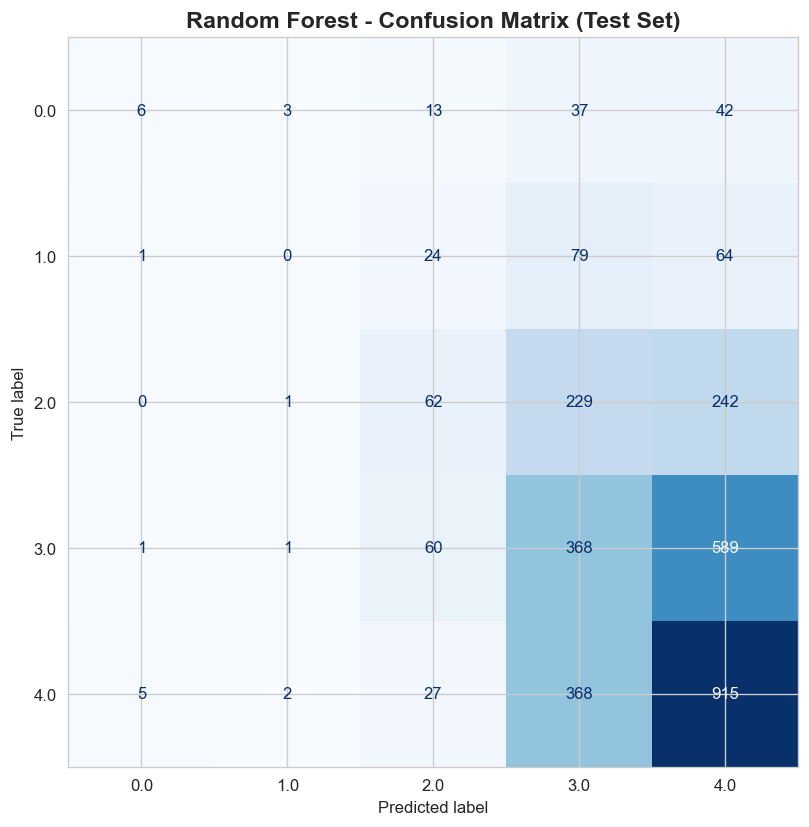

In [8]:
cm = confusion_matrix(y_test, rf_pred)
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_encoder.classes_.astype(str),
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Random Forest - Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

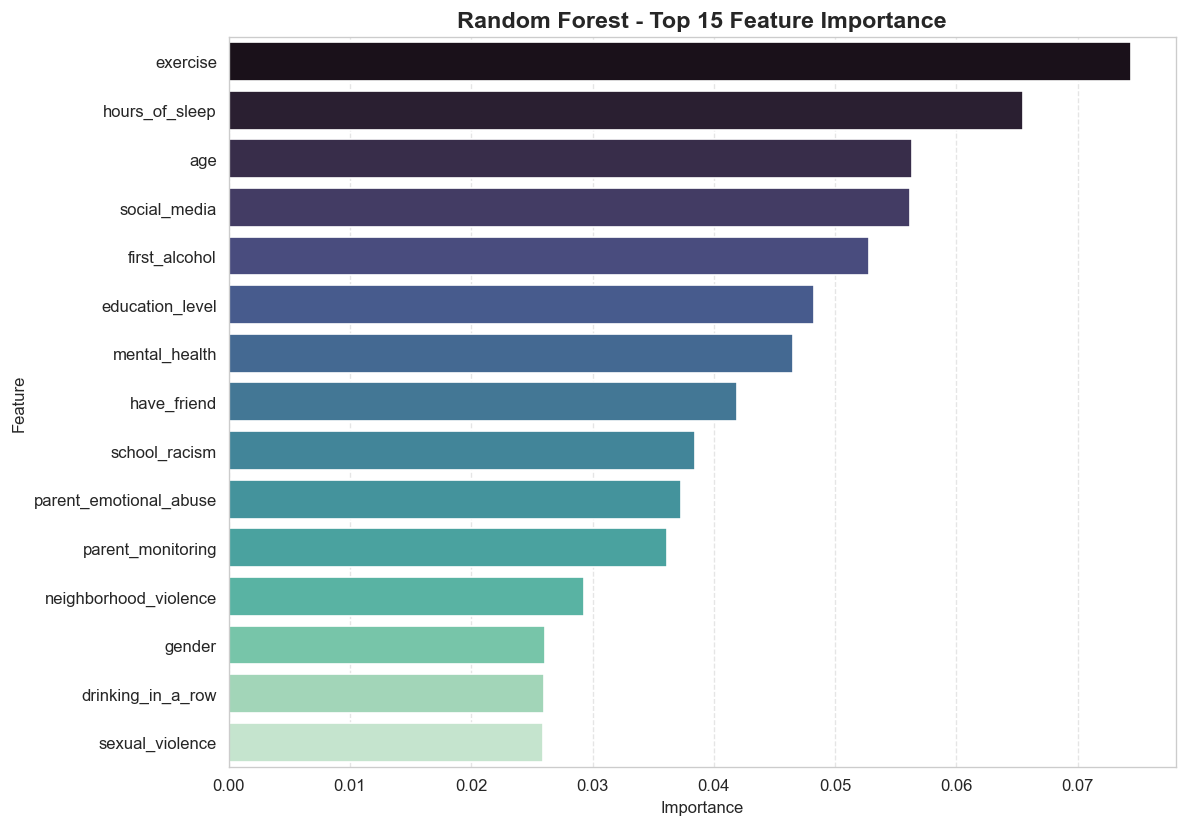

Top 10 Features:
               Feature  Importance
              exercise    0.074382
        hours_of_sleep    0.065456
                   age    0.056325
          social_media    0.056168
         first_alcohol    0.052772
       education_level    0.048222
         mental_health    0.046517
           have_friend    0.041927
         school_racism    0.038480
parent_emotional_abuse    0.037323


In [9]:
# Feature importance for Random Forest
rf_imp_df = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': rf_best.feature_importances_,
}).sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=rf_imp_df, x='Importance', y='Feature', palette='mako', ax=ax)
ax.set_title('Random Forest - Top 15 Feature Importance', fontsize=14, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Top 10 Features:")
print(rf_imp_df.head(10).to_string(index=False))

## XGBoost

In [10]:
# Basic XGBoost model
xgb_basic = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, objective='multi:softprob', num_class=5, random_state=RANDOM_STATE, verbosity=0)
xgb_basic.fit(X_train, y_train)

xgb_basic_pred = xgb_basic.predict(X_test)
xgb_basic_acc = accuracy_score(y_test, xgb_basic_pred)

print(f"  Accuracy: {xgb_basic_acc:.4f}")

  Accuracy: 0.4444


### 3-Class Grouping & SMOTE

In [11]:
# Group grades into 3 classes: Low (F,D), Mid (C), High (B,A)
grade_group_map = {0: 0, 1: 0, 2: 1, 3: 2, 4: 2}
y_grouped = pd.Series(y_train).map(grade_group_map).values
y_test_grouped = pd.Series(y_test).map(grade_group_map).values

smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_grouped)

print(f"Original class distribution: {pd.Series(y_grouped).value_counts().sort_index().to_dict()}")
print(f"After SMOTE: {pd.Series(y_train_smote).value_counts().sort_index().to_dict()}")

xgb_grouped = XGBClassifier(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=3,
    min_child_weight=5,
    subsample=0.7,
    colsample_bytree=0.7,
    objective='multi:softprob',
    num_class=3,
    random_state=RANDOM_STATE,
    verbosity=0
)
xgb_grouped.fit(X_train_smote, y_train_smote)

xgb_grouped_pred = xgb_grouped.predict(X_test)
xgb_grouped_acc = accuracy_score(y_test_grouped, xgb_grouped_pred)

print(f"Accuracy: {xgb_grouped_acc:.4f}")

Original class distribution: {0: 1079, 1: 2133, 2: 9343}
After SMOTE: {0: 9343, 1: 9343, 2: 9343}
Accuracy: 0.7238


In [12]:
print(classification_report(
    y_test_grouped, xgb_grouped_pred,
    target_names=['Low (F-D)', 'Mid (C)', 'High (B-A)'],
    zero_division=0
))

              precision    recall  f1-score   support

   Low (F-D)       0.26      0.25      0.25       269
     Mid (C)       0.30      0.01      0.03       534
  High (B-A)       0.77      0.94      0.85      2336

    accuracy                           0.72      3139
   macro avg       0.44      0.40      0.38      3139
weighted avg       0.65      0.72      0.66      3139



### Feature Engineering

In [13]:
# Feature engineering for comprehensive analysis
print("Creating engineered features...")
df_fe = df.copy()

# Health & Lifestyle
health_cols = ['hours_of_sleep', 'exercise', 'mental_health', 'ADHD']
df_fe['health_score'] = df_fe[health_cols].sum(axis=1)
df_fe['health_risk'] = ((df_fe['hours_of_sleep'] < 7) | (df_fe['mental_health'] > 2) | (df_fe['ADHD'] > 0)).astype(int)
df_fe['sleep_exercise_interaction'] = df_fe['hours_of_sleep'] * df_fe['exercise']
df_fe['mental_adhd_interaction'] = df_fe['mental_health'] * df_fe['ADHD']

# Alcohol Use
alcohol_cols = ['first_alcohol', 'alcohol_frequency', 'hardcore_alcohol_frequency', 'drinking_in_a_row']
df_fe['alcohol_exposure'] = df_fe[alcohol_cols].sum(axis=1)
df_fe['alcohol_progression'] = df_fe['alcohol_frequency'] - df_fe['first_alcohol']
df_fe['high_alcohol_use'] = ((df_fe['alcohol_frequency'] > 0) | (df_fe['hardcore_alcohol_frequency'] > 0)).astype(int)

# Family Environment
family_cols = ['parent_emotional_abuse', 'parent_physical_abuse', 'parent_abuse_parent', 
               'parent_uses_alcohol', 'parent_mental_illness', 'incarcerated_parent', 'parent_monitoring']
df_fe['family_adversity_score'] = df_fe[family_cols[:-1]].sum(axis=1)
df_fe['family_protective_score'] = df_fe['parent_monitoring'] + df_fe['have_friend']
df_fe['family_risk_ratio'] = df_fe['family_adversity_score'] / (df_fe['family_protective_score'] + 1)

# School Environment
school_cols = ['school_safety_concern', 'threatened_at_school', 'school_fight_count', 
               'school_racism', 'school_bullying', 'unfair_discipline_school']
df_fe['school_stress_score'] = df_fe[school_cols].sum(axis=1)
df_fe['bullying_exposure'] = ((df_fe['school_bullying'] > 0) | (df_fe['cyber_bullying'] > 0)).astype(int)
df_fe['school_violence_index'] = df_fe['school_safety_concern'] + df_fe['threatened_at_school'] + df_fe['school_fight_count']

# Social & Peer
df_fe['social_engagement'] = df_fe['social_media'] + df_fe['have_friend']
df_fe['social_risk'] = (df_fe['social_media'] > 5).astype(int)
df_fe['peer_support'] = df_fe['have_friend']

# Violence & Safety
violence_cols = ['fight_count', 'neighborhood_violence', 'sexual_violence', 'ride_drinking_driver']
df_fe['violence_exposure_score'] = df_fe[violence_cols].sum(axis=1)
df_fe['personal_violence'] = df_fe['fight_count'] + df_fe['sexual_violence']
df_fe['environmental_violence'] = df_fe['neighborhood_violence'] + df_fe['ride_drinking_driver']

# Demographic & Cross-domain
df_fe['age_squared'] = df_fe['age'] ** 2
df_fe['adolescent_risk'] = ((df_fe['age'] >= 14) & (df_fe['age'] <= 17)).astype(int)
df_fe['health_substance_risk'] = df_fe['health_risk'] * df_fe['high_alcohol_use']
df_fe['family_school_stress'] = df_fe['family_adversity_score'] * df_fe['school_stress_score']
df_fe['social_violence_link'] = df_fe['social_risk'] * df_fe['violence_exposure_score']

print(f"✓ Feature engineering complete")
print(f"  Original features: {X.shape[1]}")
print(f"  New engineered features: {df_fe.shape[1] - df.shape[1]}")
print(f"  Total features: {df_fe.shape[1]}")

Creating engineered features...
✓ Feature engineering complete
  Original features: 34
  New engineered features: 24
  Total features: 59


In [14]:
# Prepare data with engineered features
categorical_cols = ['gender', 'education_level', 'considered_suicide', 'sleep_place']
numeric_cols = [col for col in df_fe.columns if col not in categorical_cols + ['grade']]

X_fe = df_fe[numeric_cols + categorical_cols].copy()

# Handle missing values
X_fe = X_fe.fillna(X_fe.median(numeric_only=True))
for col in categorical_cols:
    X_fe[col] = X_fe[col].fillna(X_fe[col].mode()[0])

# Label encode categoricals
for col in categorical_cols:
    X_fe[col] = LabelEncoder().fit_transform(X_fe[col].astype(str))

y_fe = y_encoded

# Split data
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y_fe, test_size=0.2, random_state=RANDOM_STATE, stratify=y_fe
)

# Apply SMOTE
smote_fe = SMOTE(random_state=RANDOM_STATE)
X_train_fe_smote, y_train_fe_smote = smote_fe.fit_resample(X_train_fe, y_train_fe)

print(f"Engineered feature set prepared")
print(f"  Train: {X_train_fe_smote.shape[0]:,} samples (after SMOTE)")
print(f"  Test:  {X_test_fe.shape[0]:,} samples")

Engineered feature set prepared
  Train: 26,340 samples (after SMOTE)
  Test:  3,139 samples


In [15]:
# Train full 5-class XGBoost with engineered features
print("Training XGBoost with engineered features (5-class)...")
xgb_full = XGBClassifier(
    n_estimators=700,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=5,
    random_state=RANDOM_STATE,
    verbosity=0
)
xgb_full.fit(X_train_fe_smote, y_train_fe_smote)

# Evaluate
xgb_full_pred = xgb_full.predict(X_test_fe)
xgb_full_acc = accuracy_score(y_test_fe, xgb_full_pred)

print(f"✓ XGBoost (5-class with engineering) trained")
print(f"  Accuracy: {xgb_full_acc:.4f}")

Training XGBoost with engineered features (5-class)...
✓ XGBoost (5-class with engineering) trained
  Accuracy: 0.4326


In [16]:
# Detailed evaluation for full model
print("5-Class XGBoost with Feature Engineering - Classification Report:")
print(classification_report(
    y_test_fe, xgb_full_pred,
    target_names=['F', 'D', 'C', 'B', 'A'],
    zero_division=0
))

5-Class XGBoost with Feature Engineering - Classification Report:
              precision    recall  f1-score   support

           F       0.25      0.14      0.18       101
           D       0.10      0.02      0.04       168
           C       0.29      0.13      0.18       534
           B       0.35      0.34      0.35      1019
           A       0.51      0.70      0.59      1317

    accuracy                           0.43      3139
   macro avg       0.30      0.27      0.27      3139
weighted avg       0.39      0.43      0.40      3139



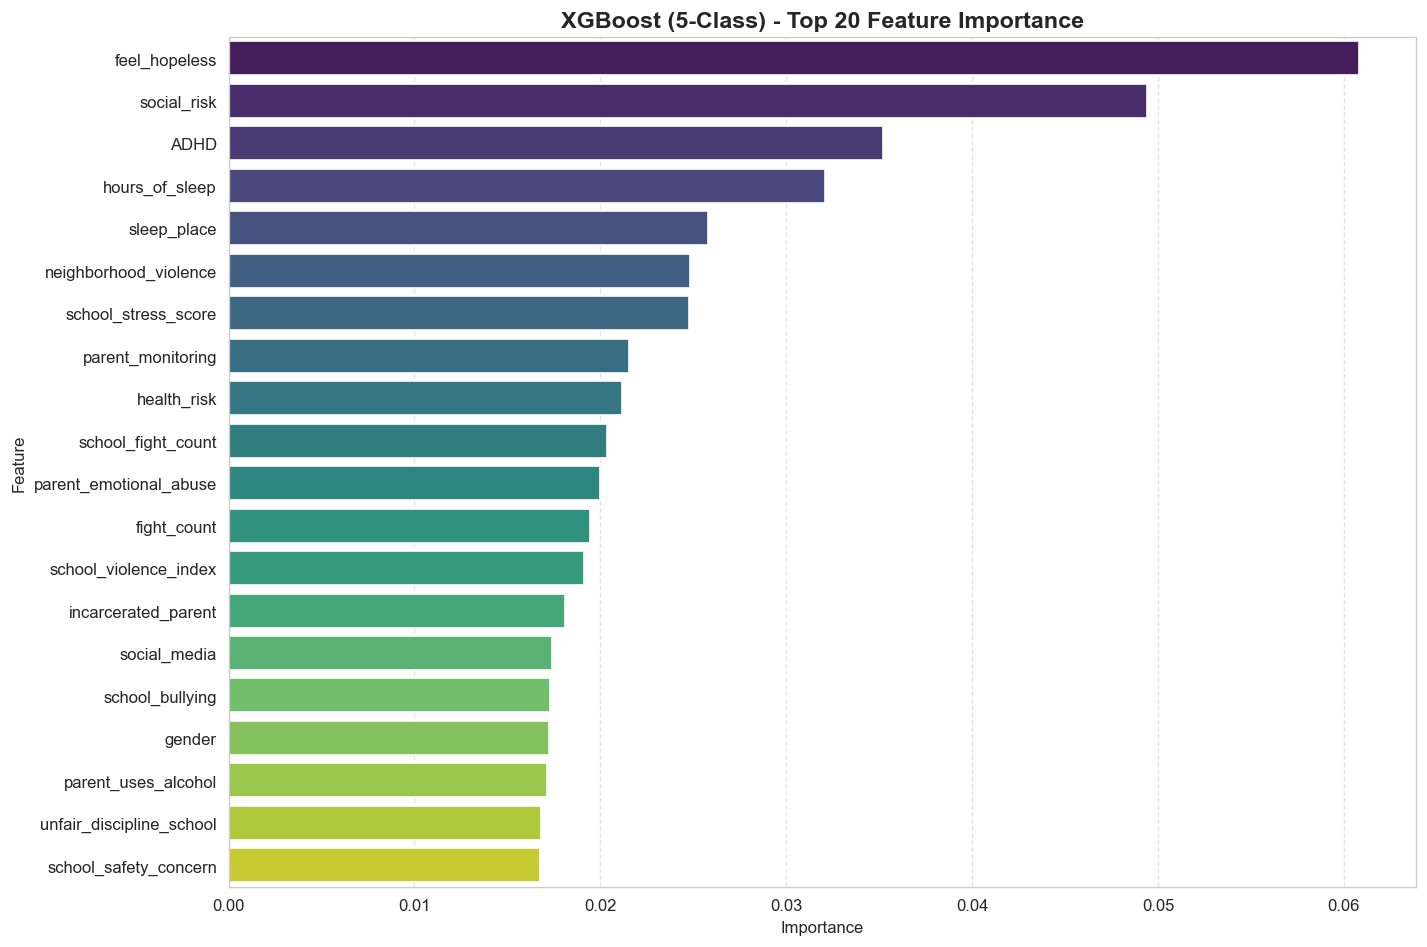

              Feature  Importance
        feel_hopeless    0.060841
          social_risk    0.049427
                 ADHD    0.035215
       hours_of_sleep    0.032077
          sleep_place    0.025772
neighborhood_violence    0.024832
  school_stress_score    0.024769
    parent_monitoring    0.021531
          health_risk    0.021185
   school_fight_count    0.020367


In [17]:
xgb_full_imp = pd.DataFrame({
    'Feature': X_fe.columns,
    'Importance': xgb_full.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=xgb_full_imp.head(20), palette='viridis', ax=ax)
ax.set_title('XGBoost (5-Class) - Top 20 Feature Importance', fontsize=14, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(xgb_full_imp.head(10).to_string(index=False))

## Comparison

In [18]:
results = [
    {
        'Model': 'Random Forest (baseline)',
        'Accuracy': rf_baseline_acc,
        'Precision': precision_score(y_test, rf_baseline_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, rf_baseline_pred, average='weighted', zero_division=0),
        'F1': f1_score(y_test, rf_baseline_pred, average='weighted', zero_division=0),
        'Type': 'Baseline'
    },
    {
        'Model': 'Random Forest (tuned)',
        'Accuracy': rf_acc,
        'Precision': rf_prec,
        'Recall': rf_rec,
        'F1': rf_f1,
        'Type': 'Tuned'
    },
    {
        'Model': 'XGBoost (basic)',
        'Accuracy': xgb_basic_acc,
        'Precision': precision_score(y_test, xgb_basic_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, xgb_basic_pred, average='weighted', zero_division=0),
        'F1': f1_score(y_test, xgb_basic_pred, average='weighted', zero_division=0),
        'Type': 'Baseline'
    },
    {
        'Model': 'XGBoost (3-class grouped)',
        'Accuracy': xgb_grouped_acc,
        'Precision': precision_score(y_test_grouped, xgb_grouped_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test_grouped, xgb_grouped_pred, average='weighted', zero_division=0),
        'F1': f1_score(y_test_grouped, xgb_grouped_pred, average='weighted', zero_division=0),
        'Type': 'Grouped'
    },
    {
        'Model': 'XGBoost (5-class engineered)',
        'Accuracy': xgb_full_acc,
        'Precision': precision_score(y_test_fe, xgb_full_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test_fe, xgb_full_pred, average='weighted', zero_division=0),
        'F1': f1_score(y_test_fe, xgb_full_pred, average='weighted', zero_division=0),
        'Type': 'Advanced'
    }
]

results_df = pd.DataFrame(results).round(4).sort_values('Accuracy', ascending=False)
print(results_df.to_string(index=False))

                       Model  Accuracy  Precision  Recall     F1     Type
   XGBoost (3-class grouped)    0.7238     0.6459  0.7238 0.6569  Grouped
             XGBoost (basic)    0.4444     0.4112  0.4444 0.4005 Baseline
XGBoost (5-class engineered)    0.4326     0.3910  0.4326 0.3987 Advanced
       Random Forest (tuned)    0.4304     0.3894  0.4304 0.3887    Tuned
    Random Forest (baseline)    0.4135     0.3817  0.4135 0.3787 Baseline
